# Import

In [10]:
#%pip install keras tensorflow

# --- Standard Library ---
import os
from typing import Dict, List, Optional, Tuple

# --- Data Manipulation & Math ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# --- Machine Learning: Scikit-Learn ---
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import mean_squared_error, precision_recall_fscore_support
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- Deep Learning: TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, 
    Dropout, 
    Input, 
    LSTM, 
    RepeatVector, 
    TimeDistributed
)
from tensorflow.keras.models import Model, Sequential
# from tensorflow.keras.callbacks import EarlyStopping

# --- Deep Learning: PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Local Modules ---
from models import LSTMAnomalyDetector

# PARAMETERS & CONSTANTS & CLASSES


In [16]:
# PARAMETERS & CONSTANTS & CLASSES

# New column name for local time with timezone awareness if needed
LOCAL_DATETIME_ZONEAWARE = "Local_Time_Aware"

LOCAL_TIME = "Lcl Time" # column name for local naive time %H:%M:%S

# New column name for normalized flight progress. 0 is start of flight, 1 is end of flight.
FLIGHT_PROGRESS_NORM = "Flight_Progress (0-1)"

# Parameters to analyze for decoupling
COL_RPM = 'E1 RPM'       # E1 RPM (Uses the literal header name) 'rpm'
COL_CHT = 'E1 CHT4'      # E1 CHT4 (Corrected: 4th deg F column) 'deg F.4'
COL_EGT = 'E1 EGT4'      # E1 EGT4 (Corrected: 8th deg F column) 'deg F.8'

# The feature set used for anomaly detection will include the three engine parameters
# plus the normalized time feature created in the data cleaning function.
FEATURE_COLUMNS = [COL_RPM, COL_CHT, COL_EGT]

# Rolling window size for correlation calculation.
# If the log is sampled once per second, a window of 60 means the correlation 
# is calculated over the previous minute of flight data.
ROLLING_WINDOW_SIZE = 256 # seconds
STRIDE = 8 # how much to slide the window for each new calculation

# Isolation Forest Hyperparameters
# Contamination is the expected proportion of outliers in the dataset. 
# A typical value for rare anomalies is between 0.01 (1%) and 0.05 (5%).
CONTAMINATION_RATE = 0.05

# Name of labeled anomaly column (ground truth)
LABELED_ANOMALY_COL = 'isAnomalyLabeled'

# Name of predicted anomaly column
PREDICTED_ANOMALY_COL = 'predictedAnomaly'

class Flight:
    TIME_COL = LOCAL_TIME  # Class attribute for the time column name
    
    def __init__(self, file_path: str, anomaly_label: Optional[Tuple[str, str]] = None):
        self.file_path = file_path
        self.file_name = os.path.basename(file_path)
        
        # Load Data
        self.dataframe = pd.read_csv(file_path)
        if self.dataframe.empty:
            raise ValueError(f"File {file_path} is empty.")
        
        # 2. Clean and Convert the time column
        if self.TIME_COL in self.dataframe.columns:
            # First, cast to string and strip spaces/newlines
            self.dataframe[self.TIME_COL] = self.dataframe[self.TIME_COL].astype(str).str.strip()
            
            # Now convert to datetime
            self.dataframe[self.TIME_COL] = pd.to_datetime(
                self.dataframe[self.TIME_COL], 
                format='%H:%M:%S', 
                errors='coerce'
            )
            
            # Final check to ensure we didn't get all NaTs
            if self.dataframe[self.TIME_COL].isna().all():
                print(f"Warning: All times in {self.file_name} are NaT. Check column format.")
        else:
            raise KeyError(f"Time column '{self.TIME_COL}' not found in {file_path}.")
                
        # Validation and Conversion for anomaly labels (parse to datetimes)
        if anomaly_label:
            # Use the EXACT same format as the dataframe conversion
            # This forces the date to 1900-01-01
            start_anom = pd.to_datetime(anomaly_label[0].strip(), format='%H:%M:%S', errors='coerce')
            end_anom = pd.to_datetime(anomaly_label[1].strip(), format='%H:%M:%S', errors='coerce')
            
            if pd.isna(start_anom) or pd.isna(end_anom):
                raise ValueError(f"Could not parse anomaly labels for {self.file_name}")
                
            self.anomaly_label = (start_anom, end_anom)

    @property
    def start_time(self) -> pd.Timestamp:
        return self.dataframe[self.TIME_COL].min()

    @property
    def end_time(self) -> pd.Timestamp:
        return self.dataframe[self.TIME_COL].max()

    def get_duration(self) -> pd.Timedelta:
        return self.end_time - self.start_time
    
    def createRegressionWindows(self, target_col, window_size=ROLLING_WINDOW_SIZE, step_size=STRIDE):
        """
        Creates windows where X is the feature window (flattened)
        and y is the VALUE of the target_col at the end of the window.
        Returns X, y as numpy arrays ready for regression models like Random Forest Regressor.
        """
        X = []
        y = []
        
        # We drop the target column from features to prevent data leakage
        # (We want to predict EGT using only RPM and CHT, for example)
        feature_cols = [c for c in FEATURE_COLUMNS if c != target_col]
        
        features = self.dataframe[feature_cols].values
        targets = self.dataframe[target_col].values
        
        for i in range(0, len(self.dataframe) - window_size, step_size):
            # Extract the window of input features
            window = features[i : i + window_size]
            
            # Set target as the middle point of the window to avoid data leakage (or you can choose the end point)
            middle_idx = i + window_size // 2
            target_val = targets[middle_idx] # This is the value we want to predict
            
            X.append(window.flatten()) # Flatten for Random Forest
            y.append(target_val)
            
        return np.array(X), np.array(y)
    
    def standardizeFeatures(self, feature_cols=FEATURE_COLUMNS):
        """Standardizes the specified feature columns using z-score normalization.
        This is important for models like Isolation Forest and LSTM to ensure all features are on a similar scale.
        """
        scaler = StandardScaler()
        self.dataframe[feature_cols] = scaler.fit_transform(self.dataframe[feature_cols])
        return scaler # Return the scaler for later use in test data or LSTM input scaling

    # LSTM-AutoEncoder Anomaly Detection
    def detectAnomaliesLSTM_AE(self, model, scaler, threshold, window_size=ROLLING_WINDOW_SIZE):
        # 1. Prepare Features (Ensure we use the exact same columns as training)
        data_subset = self.dataframe[FEATURE_COLUMNS].copy()
        
        # We must handle NaNs exactly like the training data did
        # For LSTMs, we usually forward-fill then drop remaining to keep sequence integrity
        data_subset = data_subset.ffill().fillna(0) 
        
        # 2. Generate Windows
        X, _ = self.create_windows(window_size=window_size, is_lstm=True)
        
        if len(X) == 0:
            print(f"No windows created for {self.file_name}. Data might be too short.")
            return

        # 3. Scale and Predict
        B, T, F = X.shape
        X_scaled = scaler.transform(X.reshape(-1, F)).reshape(B, T, F)
        X_tensor = torch.FloatTensor(X_scaled)
        
        model.eval()
        with torch.no_grad():
            reconstructions = model(X_tensor)
            # Calculate MSE: mean over the (Timesteps x Features) dimensions
            mse = torch.mean((X_tensor - reconstructions)**2, dim=(1, 2)).numpy()

        import matplotlib.pyplot as plt

        # Inside detectAnomaliesLSTM_AE...
        plt.hist(mse, bins=50)
        plt.axvline(threshold, color='r', linestyle='--')
        plt.title(f"MSE Distribution for {self.file_name}")
        plt.show()
        
        # 4. Critical Mapping: Align predictions to DataFrame
        # Predictions represent the END of a window.
        # If window_size is 60, the first prediction is for the 60th row (index 59).
        predictions = mse > threshold
        
        # Initialize column
        self.dataframe[PREDICTED_ANOMALY_COL] = 0
        
        # Map the boolean array to the correct slice of the dataframe
        # We start at window_size - 1 and go until we run out of predictions
        start_idx = window_size - 1
        end_idx = start_idx + len(predictions)
        
        self.dataframe.iloc[start_idx:end_idx, self.dataframe.columns.get_loc(PREDICTED_ANOMALY_COL)] = predictions.astype(int)

        # 5. Summary Stats
        num_anomalies = self.dataframe[PREDICTED_ANOMALY_COL].sum()
        print(f"Flight {self.file_name}: Found {num_anomalies} anomalous points (Threshold: {threshold:.6f})")

    def ensureNumericEngineData(self):
        # Convert engine data columns to numeric, coercing errors to NaN
        self.dataframe[COL_RPM] = pd.to_numeric(self.dataframe[COL_RPM], errors='coerce')
        self.dataframe[COL_CHT] = pd.to_numeric(self.dataframe[COL_CHT], errors='coerce')
        self.dataframe[COL_EGT] = pd.to_numeric(self.dataframe[COL_EGT], errors='coerce')
        # Optionally, handle NaN values (e.g., drop or fill)
        #self.dataframe.dropna(subset=[COL_RPM, COL_CHT, COL_EGT], inplace=True)

    def normalizeFlightProgress(self, timeColumn: str):
        """create a new column in the dataframe that normalizes flight progress from 0 to 1"""
        total_duration = self.get_duration().total_seconds()
        self.dataframe[FLIGHT_PROGRESS_NORM] = (
            (pd.to_datetime(self.dataframe[timeColumn]) - self.start_time).dt.total_seconds() 
            / total_duration
        )

    def labelAnomaly(self):
        """
        Converts the start/end anomaly_label tuple into a 0 or 1 column LABELED_ANOMALY_COL.
        This creates the 'Ground Truth' for supervised learning.
        """
        if self.anomaly_label is None:
            # If no label exists, we assume the whole flight is normal (0)
            self.dataframe[LABELED_ANOMALY_COL] = 0
            return
        start_anom, end_anom = self.anomaly_label
        # marks rows within the anomaly period as 1, else 0
        self.dataframe[LABELED_ANOMALY_COL] = (
            (self.dataframe[self.TIME_COL] >= start_anom) &
            (self.dataframe[self.TIME_COL] <= end_anom)
        ).astype(int)

    def create_windows(self, window_size=ROLLING_WINDOW_SIZE, step_size=STRIDE, is_lstm=True):
        """
        Creates sliding windows of flight data for training.
        """
        X = [] 
        y = [] 
        
        # Extract features and labels
        features = self.dataframe[[COL_RPM, COL_EGT, COL_CHT]].values
        labels = self.dataframe[LABELED_ANOMALY_COL].values
        
        # Pre-create a time index for the slope calculation (x-axis)
        t = np.arange(window_size)

        for i in range(0, len(self.dataframe) - window_size, step_size):
            window = features[i : i + window_size]
            
            # Labeling Logic (kept as "any" based on our previous discussion to boost recall)
            labelStyle = "any" 
            match labelStyle:
                case "any":
                    window_label = 1 if labels[i : i + window_size].sum() > 0 else 0
                case "all":
                    window_label = 1 if labels[i : i + window_size].all() else 0
                case "last":
                    window_label = labels[i + window_size - 1]
                case "middle":
                    window_label = labels[i + window_size // 2]
                case "majority":
                    window_label = 1 if labels[i : i + window_size].mean() > 0.5 else 0
                case _:
                    raise ValueError(f"Unknown labelStyle: {labelStyle}")

            if is_lstm:
                X.append(window)
            else:
                # Aggregated Statistics per sensor
                window_stats = []
                # Calculate stats for each sensor (RPM, EGT, CHT)
                for sensor_idx in range(window.shape[1]):
                    sensor_data = window[:, sensor_idx]
                    
                    # LSRL Slope Calculation
                    # Using polyfit(deg=1) to get the slope (index 0 of the result)
                    slope = np.polyfit(t, sensor_data, 1)[0]
                    
                    # Appending features in order: mean, std, median, min, max, slope, first, last
                    window_stats.extend([
                        np.mean(sensor_data),
                        np.std(sensor_data),
                        np.median(sensor_data),
                        np.min(sensor_data),
                        np.max(sensor_data),
                        slope,
                        sensor_data[0],
                        sensor_data[-1]
                    ])
                X.append(window_stats)
                
            y.append(window_label)

        return np.array(X), np.array(y)

    def detectAnomaliesIsolationForest(self, features: List[str], contamination: float = 0.01):
        """
        Performs Isolation Forest unsupervised anomaly detection on the specified features on a single flight log.
        Adds an PREDICTED_ANOMALY_COL and 'anomaly_score' column to the flight dataframe.
        Print the accuracy, precision, recall, and F1-score if anomaly labels are provided.
        """
        # 1. Prepare data (dropping NaNs is crucial for sklearn)
        data_to_fit = self.dataframe[features].dropna()
        
        if data_to_fit.empty:
            print(f"No data available for anomaly detection in {self.file_name}")
            return

        # 2. Scale features
        # Isolation Forest is distance-agnostic, but scaling is good practice
        # when combining units like RPM (2500) and CHT (350).
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data_to_fit)

        # 3. Initialize and Fit Isolation Forest
        model = IsolationForest(
            contamination=contamination, 
            random_state=42,
            n_estimators=100
        )
        
        # Predict: -1 for anomalies, 1 for normal data
        predictions = model.fit_predict(scaled_data)
        scores = model.decision_function(scaled_data) # Lower = more anomalous

        # 4. Map results back to the original dataframe
        # We use a join/reindex approach to ensure rows with NaNs are handled
        results_df = pd.DataFrame(
            {PREDICTED_ANOMALY_COL: predictions, 'anomaly_score': scores}, 
            index=data_to_fit.index
        )
        
        # Join results back to the main dataframe (replace if already exists)
        if PREDICTED_ANOMALY_COL in self.dataframe.columns:
            self.dataframe.drop(columns=PREDICTED_ANOMALY_COL, inplace=True)
        if 'anomaly_score' in self.dataframe.columns:
            self.dataframe.drop(columns='anomaly_score', inplace=True)
        self.dataframe = self.dataframe.join(results_df)
        
        # Convert -1/1 to True/False for easier filtering
        self.dataframe[PREDICTED_ANOMALY_COL] = self.dataframe[PREDICTED_ANOMALY_COL] == -1
      
        # Print accuracy, precision, recall, and F1-score if anomaly labels are provided
        if self.anomaly_label is not None:
            start_anom, end_anom = self.anomaly_label

            valid_idx = self.dataframe[PREDICTED_ANOMALY_COL].notna()

            true_labels = (
                (self.dataframe.loc[valid_idx, self.TIME_COL] >= start_anom) &
                (self.dataframe.loc[valid_idx, self.TIME_COL] <= end_anom)
            )

            pred_labels = self.dataframe.loc[valid_idx, PREDICTED_ANOMALY_COL]

            precision, recall, f1, _ = precision_recall_fscore_support(
                true_labels.to_numpy(),
                pred_labels.to_numpy(),
                average='binary',
                zero_division=0
            )

            #print("Label window:", start_anom, "→", end_anom)
            #print("First time:", self.dataframe[self.TIME_COL].min())
            #print("Last time:", self.dataframe[self.TIME_COL].max())
            #print("True anomaly points:", true_labels.sum())        

            accuracy = (true_labels == pred_labels).mean()

            print(
                f"Flight {self.file_name} - "
                f"Accuracy: {accuracy:.4f}, "
                f"Precision: {precision:.4f}, "
                f"Recall: {recall:.4f}, "
                f"F1-Score: {f1:.4f}"
            )

    def get_window_times(self, window_size):
        """
        Returns normalized time (0–1) for each window,
        using the END of the window as its timestamp.
        """
        times = self.dataframe[FLIGHT_PROGRESS_NORM].values
        return times[window_size - 1:]

    def plotEngineCorrelation(self, data1, data2):
        """
        Plots the rolling correlation between two engine parameters over normalized flight progress.
        """
        #df = Flight.dataframe
        plt.figure(figsize=(12, 6))
        rolling_corr = self.dataframe[data1].rolling(window=ROLLING_WINDOW_SIZE).corr(self.dataframe[data2])
        plt.plot(self.dataframe[FLIGHT_PROGRESS_NORM], rolling_corr, label=f'Rolling Correlation: {data1} & {data2}', color='purple')
        # add a vertical line at the anomaly start and end if available
        if self.anomaly_label is not None:
            start_anom, end_anom = self.anomaly_label
            start_progress = (start_anom - self.start_time).total_seconds() / self.get_duration().total_seconds()
            end_progress = (end_anom - self.start_time).total_seconds() / self.get_duration().total_seconds()
            plt.axvline(x=start_progress, color='red', linestyle='--', label='Anomaly Start')
            plt.axvline(x=end_progress, color='orange', linestyle='--', label='Anomaly End')
        plt.title(f'Rolling Correlation between {data1} and {data2} Over Flight Progress')
        plt.xlabel('Flight Progress (0-1)')
        plt.ylabel('Correlation Coefficient')
        plt.legend()
        plt.grid()
        plt.show()


    def plotActualAnomaly(self, title_suffix=""):
        """
        Plots Actual anomaly periods for a single Flight object.
        The plot spans the entire flight duration (start to end).
        """
        df = self.dataframe
        if df.empty:
            print(f"No data to plot for {self.file_name}")
            return

        time = df[self.TIME_COL]
        
        # 1. Define the full flight boundaries
        start_time = time.min()
        end_time = time.max()

        # Ensure we have our ground truth labels
        if LABELED_ANOMALY_COL in df.columns:
            actual = df[LABELED_ANOMALY_COL].fillna(0).astype(int).values
        else:
            actual = [0] * len(df) # Assume all normal if column missing

        fig, ax = plt.subplots(figsize=(15, 2)) # Adjust height as needed
        
        # 2. Plot a background "Normal" bar spanning the FULL duration
        # This ensures the visual starts at 0 and ends at 100% flight progress
        ax.hlines(y=2, xmin=start_time, xmax=end_time, color='lightgray', linewidth=25, alpha=0.3)

        # 3. Overlay the Actual Anomaly
        # where=(actual == 1) highlights only the anomalous regions
        ax.fill_between(time, 1.6, 2.4, where=(actual == 1), color='forestgreen', alpha=0.9)
        
        # 4. Force X-Axis limits to the exact flight start/end
        ax.set_xlim([start_time, end_time])

        # Formatting
        ax.set_yticks([2])
        ax.set_yticklabels(['Actual Label'])
        ax.set_ylim(1, 3) # Keep the Y-axis tight around the bar
        
        ax.set_title(f"Anomaly Timing Comparison: {self.file_name} {title_suffix}")
        ax.set_xlabel("Local Time")
        
        # Format the time labels nicely (e.g. 10:30, 10:45)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        
        # Custom Legend
        green_patch = mpatches.Patch(color='forestgreen', label='Anomaly')
        gray_patch = mpatches.Patch(color='lightgray', label='Normal Flight')
        ax.legend(handles=[green_patch, gray_patch], loc='upper right')

        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


    def replaceZoneAwareDateTime(df):
        """
        for a given flight log CSV as DF, converts local time to a timezone-aware datetime. 
        Replaces the original date/time columns with a single timezone-aware datetime column.
        Returns the modified DataFrame.
        Only call this function if you need just the datetime conversion with timezone data.
        Won't need this function for these files.
        """
        
    def randomForestAnomalyDetection(self):
        """Performs supervised anomaly detection using a Random Forest classifier.
        This function assumes that the flight log has been labeled with anomalies."""

class Manager:
    def __init__(self):
        self._flights: Dict[str, Flight] = {} # key: file_name, value: Flight object instance

    def add_flight(self, file_path, anomaly_label):
        flight = Flight(file_path, anomaly_label) # This creates a NEW Flight log
        self._flights[flight.file_name] = flight # Store it in the dictionary

    def get_flight(self, file_name: str) -> Optional[Flight]:
        return self._flights.get(file_name)

    def list_all_files(self) -> List[str]:
        return list(self._flights.keys())
    
    def get_data_for_flights(self, flight_names: List[str], window_size=ROLLING_WINDOW_SIZE, is_lstm=False):
        """Collects windows from a SPECIFIC list of flights (used for Train/Test splitting).
        """
        all_X = []
        all_y = []
        
        for name in flight_names:
            flight = self._flights[name]
            # Generate windows for THIS specific flight
            X, y = flight.create_windows(window_size=window_size, is_lstm=is_lstm)
            all_X.append(X)
            all_y.append(y)
        
        # Vertically stack all windows from all selected flights
        return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)

    def prepare_supervised_data(self, window_size=ROLLING_WINDOW_SIZE, is_lstm=False):
        """Convenience method to get data from EVERY flight in the manager.
        """
        return self.get_data_for_flights(list(self._flights.keys()), window_size, is_lstm)
    

# Instantiate the Manager with the specified file paths and anomaly labels
# Green labeled flights indicate easy to detect anomalies
# Red labeled flights indicate hard to detect anomalies
flightManager = Manager()
flightManager.add_flight('green/log_240819_153520_KPRC.csv', ("9:58:12", "10:03:40"))
flightManager.add_flight('green/log_240828_233954_KPRC.csv', ("17:25:16", "17:45:06"))
flightManager.add_flight('green/log_240911_162657_KPRC.csv', ("10:44:10", "10:52:51"))
flightManager.add_flight('green/log_240928_135020_KPRC.csv', ("06:50:20", "7:04:44"))
flightManager.add_flight('green/log_241003_133047_KPRC.csv', ("06:31:20", "06:33:17"))
flightManager.add_flight('green/log_241008_132939_KPRC.csv', ("06:58:10", "07:02:35"))
flightManager.add_flight('green/log_241030_192422_KPRC.csv', ("13:26:48", "13:29:10"))

#flightManager.add_flight('red/log_240610_222704_KPRC.csv', ("16:41:11", "17:03:36"))
#flightManager.add_flight('red/log_240721_173642_KPRC.csv', ("11:19:00", "11:25:05"))
#flightManager.add_flight('red/log_240922_155102_KPRC.csv', ("9:59:51", "10:00:21"))
#flightManager.add_flight('red/log_241016_155942_KPRC.csv', ("9:33:03", "9:34:45"))
#flightManager.add_flight('red/log_241031_215027_KPRC.csv', ("16:32:47", "16:39:23"))


# ensure numeric engine data and normalize flight progress for each flight
for flight in flightManager._flights.values():
    flight.ensureNumericEngineData()
    flight.normalizeFlightProgress(LOCAL_TIME)
    flight.labelAnomaly()
    #flight.plotActualAnomaly()
    #flight.create_windows()


def plot_anomaly_comparison(flight_obj, title_suffix=""):
    """
    Plots Actual vs Predicted anomaly periods for a single Flight object.
    """
    df = flight_obj.dataframe
    time = df[flight_obj.TIME_COL]
    
    # Ensure we have our ground truth labels
    # (Assuming you created a 'true_anomaly' column based on your labels)
    actual = df[LABELED_ANOMALY_COL].astype(int).values
    predicted = df[PREDICTED_ANOMALY_COL].astype(int).values # Results from your RF/LSTM
    
    fig, ax = plt.subplots(figsize=(15, 1.5))
    
    # We plot two horizontal lines/bars
    # Actual at Y=2, Predicted at Y=1
    ax.fill_between(time, 1.6, 2.4, where=(actual == 1), color='forestgreen', alpha=0.7, label='Actual')
    ax.fill_between(time, 0.6, 1.4, where=(predicted == 1), color='orangered', alpha=0.7, label='Predicted')
    
    # Formatting
    ax.set_yticks([1, 2])
    ax.set_yticklabels(['Model Prediction', 'Actual Label'])
    ax.set_title(f"Anomaly Timing Comparison: {flight_obj.file_name} {title_suffix}")
    ax.set_xlabel("Time")
    
    # Create custom legend
    #green_patch = mpatches.Patch(color='forestgreen', label='True Label')
    #red_patch = mpatches.Patch(color='orangered', label='Predicted')
    #ax.legend(handles=[green_patch, red_patch], loc='upper left')

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# check head of first flight dataframe
#flightManager._flights[flightManager.list_all_files()[3]].dataframe.head()

# R FOREST CLASSIFIER

Training on 6 flights, Testing on log_240819_153520_KPRC.csv
Accuracy: 0.6943, Precision: 0.1481, Recall: 0.4384, F1-Score: 0.2215


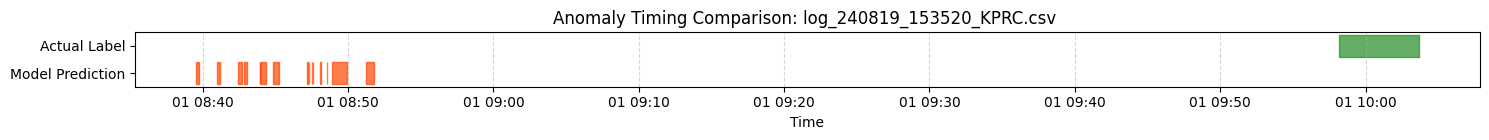

Training on 6 flights, Testing on log_240828_233954_KPRC.csv
Accuracy: 0.7707, Precision: 1.0000, Recall: 0.2953, F1-Score: 0.4560


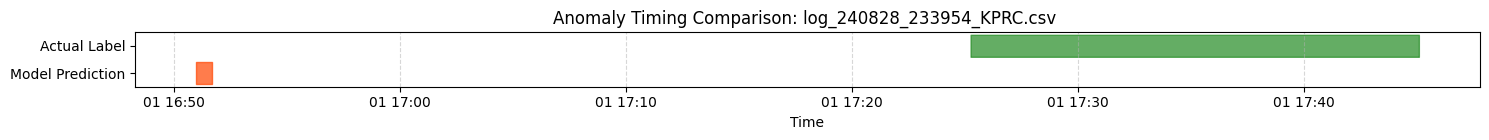

Training on 6 flights, Testing on log_240911_162657_KPRC.csv
Accuracy: 0.9347, Precision: 0.6761, Recall: 0.7385, F1-Score: 0.7059


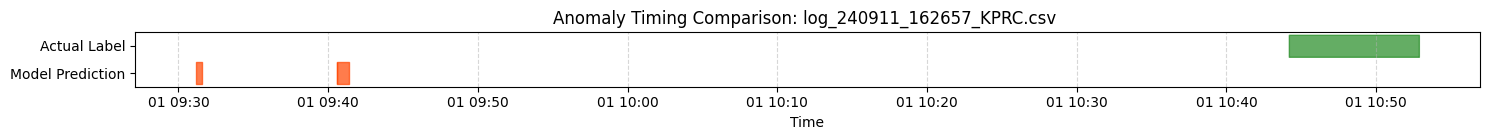

Training on 6 flights, Testing on log_240928_135020_KPRC.csv
Accuracy: 0.0000, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000


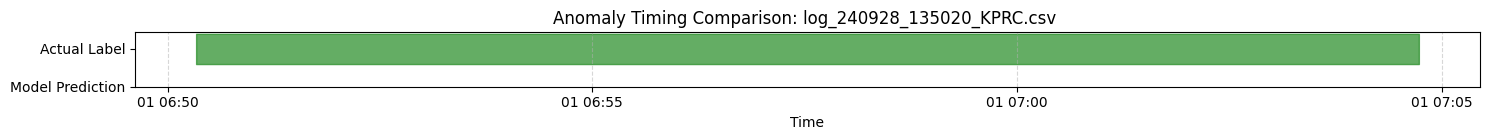

Training on 6 flights, Testing on log_241003_133047_KPRC.csv
Accuracy: 0.8077, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000


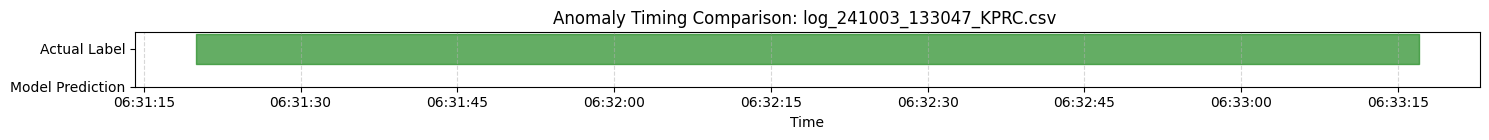

Training on 6 flights, Testing on log_241008_132939_KPRC.csv
Accuracy: 0.9409, Precision: 0.8448, Recall: 0.9074, F1-Score: 0.8750


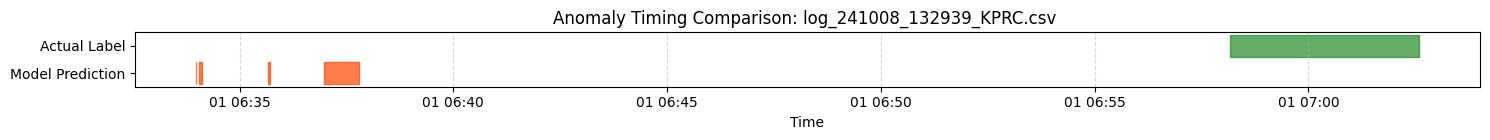

Training on 6 flights, Testing on log_241030_192422_KPRC.csv
Accuracy: 0.9251, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000


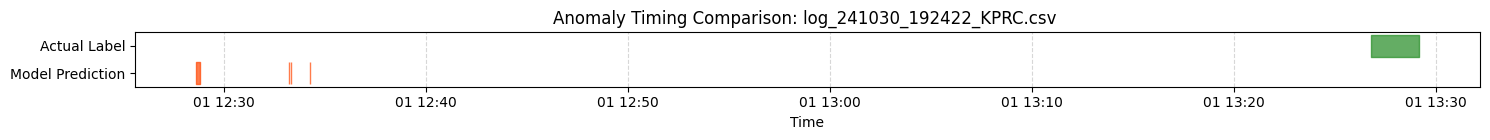

In [ ]:
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import LeaveOneGroupOut

# 1. Identify your groups (Flight IDs)
flight_names = flightManager.list_all_files()
logo = LeaveOneGroupOut()

# Check if create_windows works for one training flight
#test_flight_obj = flightManager.get_flight(flight_names[0])
#X_test, y_test = test_flight_obj.create_windows(is_lstm=False)
#print(f"Example window shape for one flight: {X_test.shape}, {y_test.shape}")
# expected output: (num_windows, num_features) for X and (num_windows,) for y

# 2. Loop through for Cross-Validation (Training on all but one flight)
for train_idx, test_idx in logo.split(flight_names, groups=flight_names):
    train_flights = [flight_names[i] for i in train_idx]
    test_flight = flight_names[test_idx[0]]
    test_flight_obj = flightManager.get_flight(test_flight)
    X_test, _ = test_flight_obj.create_windows(is_lstm=False)

    print(f"Training on {len(train_flights)} flights, Testing on {test_flight}")
    
    # 3. Aggregate data for these specific groups
    # (You might need a helper in Manager to get data for specific IDs)
    X_train, y_train = flightManager.get_data_for_flights(train_flights, is_lstm=False)
    X_test, y_test = flightManager.get_data_for_flights([test_flight], is_lstm=False)

    # GLOBAL SCALING (Fit on Train, Transform Test)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # 4. Train Model
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    
    # 5. Evaluate
    #y_pred = rf.predict(X_test)
    # 4. SENSITIVITY ADJUSTMENT (The "Recall Slider")
    # Instead of rf.predict(), use a lower threshold
    y_probs = rf.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > 0.3).astype(int) # Adjust 0.3 to find your sweet spot
    # UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0.0)
    accuracy = (y_test == y_pred).mean()
    print(
        #f"Test Flight {test_flight} - "
        f"Accuracy: {accuracy:.4f}, "
        f"Precision: {precision:.4f}, "
        f"Recall: {recall:.4f}, "
        f"F1-Score: {f1:.4f}"
    )

    # Alignment (Cleaned up)
    # create_windows ends at len(df) - window_size. 
    # We map y_pred to the END of each window.
    full_preds = np.zeros(len(test_flight_obj.dataframe))
    
    # Calculate exactly where the windows ended
    # This assumes step_size=1 for the test flight
    prediction_start_idx = ROLLING_WINDOW_SIZE
    full_preds[prediction_start_idx : prediction_start_idx + len(y_pred)] = y_pred
    
    test_flight_obj.dataframe[PREDICTED_ANOMALY_COL] = full_preds
    # 4. Plot!
    # Patch the dataframe so plot_anomaly_comparison uses the correct ground truth column
    plot_anomaly_comparison(test_flight_obj)

    '''# Align predictions back to the original dataframe
    # Note: Because of windowing, the first (window_size - 1) rows won't have predictions.
    # We pad with 0s to align.
    padding = [0] * (ROLLING_WINDOW_SIZE - 1)
    full_preds = padding + list(y_pred)

    # Ensure full_preds matches the dataframe length
    df_len = len(test_flight_obj.dataframe)
    if len(full_preds) < df_len:
        # Pad the beginning with zeros
        full_preds = [0] * (df_len - len(full_preds)) + full_preds
    elif len(full_preds) > df_len:
        # Truncate to match dataframe length
        full_preds = full_preds[:df_len]

    test_flight_obj.dataframe[PREDICTED_ANOMALY_COL] = full_preds
    '''


    

Accuracy: 0.8095, Precision: 0.2058, Recall: 0.1077, F1-Score: 0.1414


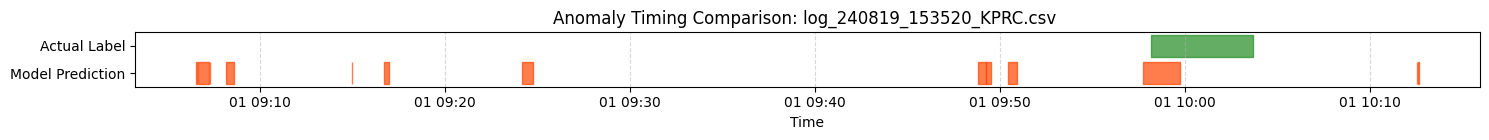

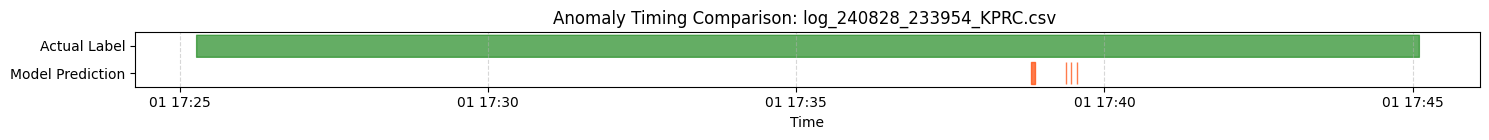

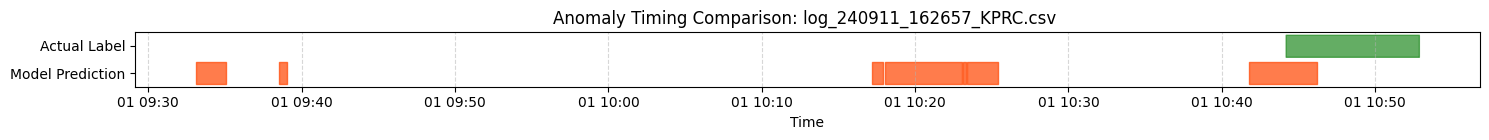

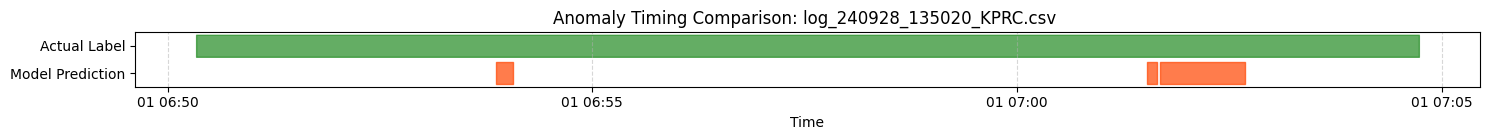

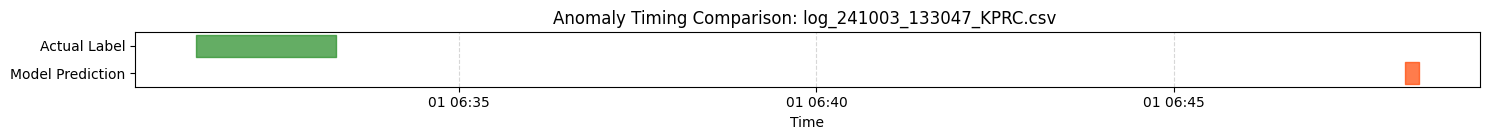

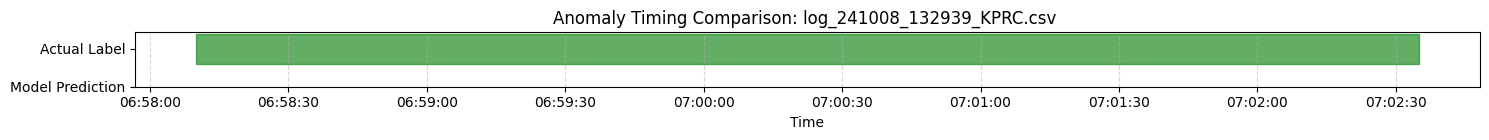

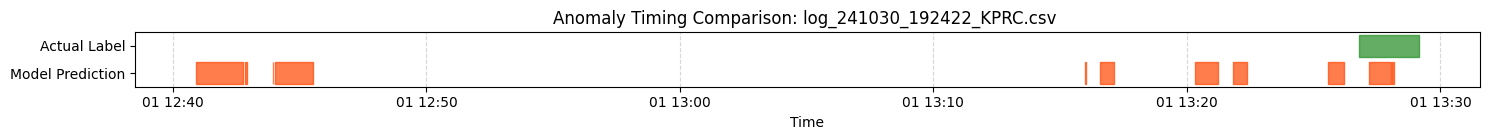

In [29]:
# Repeat the above code block of random forest cross-validation but 
# train on all red flights and test on all green flights

# 1. Identify your groups (Flight IDs)
red_flights = [f for f in flightManager.list_all_files() if "red" in flightManager.get_flight(f).file_path]
green_flights = [f for f in flightManager.list_all_files() if "green" in flightManager.get_flight(f).file_path]

# 2. Aggregate data for these specific groups
X_train, y_train = flightManager.get_data_for_flights(red_flights, is_lstm=False)
X_test, y_test = flightManager.get_data_for_flights(green_flights, is_lstm=False)

# 3. Train Model
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 4. Evaluate on all green flights
y_pred = rf.predict(X_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0.0)
accuracy = (y_test == y_pred).mean()
print(
    f"Accuracy: {accuracy:.4f}, "
    f"Precision: {precision:.4f}, "
    f"Recall: {recall:.4f}, "
    f"F1-Score: {f1:.4f}"
)

# 5. Align predictions and plot for each green flight
start_idx = 0
window_size = ROLLING_WINDOW_SIZE

for flight_name in green_flights:
    flight_obj = flightManager.get_flight(flight_name)
    X_flight, y_flight = flight_obj.create_windows(window_size=window_size, is_lstm=False)
    num_preds = len(X_flight)
    preds = y_pred[start_idx:start_idx + num_preds]
    start_idx += num_preds

    # Pad predictions to match dataframe length
    padding = [0] * (window_size - 1)
    full_preds = padding + list(preds)
    df_len = len(flight_obj.dataframe)
    if len(full_preds) < df_len:
        full_preds = [0] * (df_len - len(full_preds)) + full_preds
    elif len(full_preds) > df_len:
        full_preds = full_preds[:df_len]

    flight_obj.dataframe[PREDICTED_ANOMALY_COL] = full_preds
    flight_obj.dataframe[LABELED_ANOMALY_COL] = flight_obj.dataframe[LABELED_ANOMALY_COL]
    plot_anomaly_comparison(flight_obj)


# R FOREST REGRESSION

--- Reconstructing E1 EGT4 for log_240819_153520_KPRC.csv ---


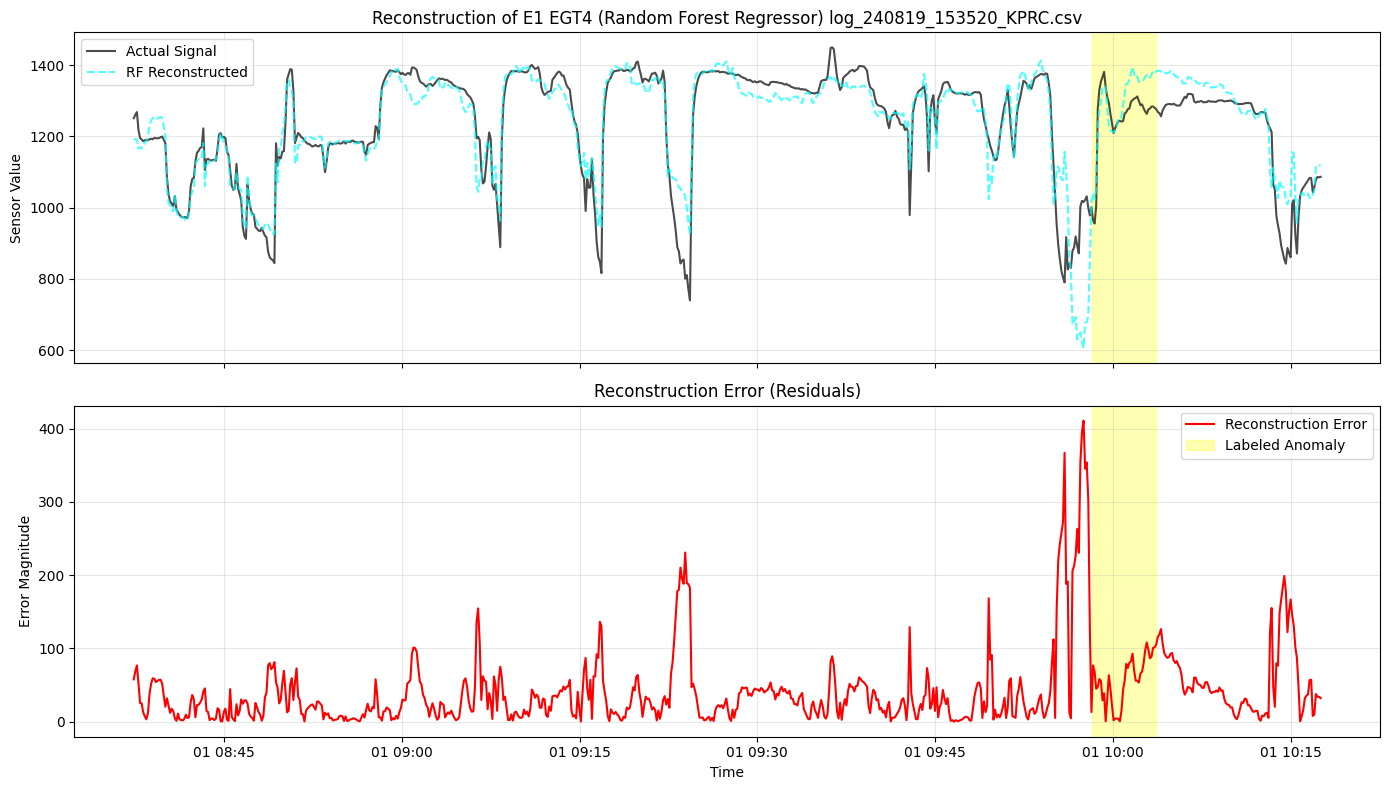

RMSE for log_240819_153520_KPRC.csv: 67.5394
--- Reconstructing E1 EGT4 for log_240828_233954_KPRC.csv ---


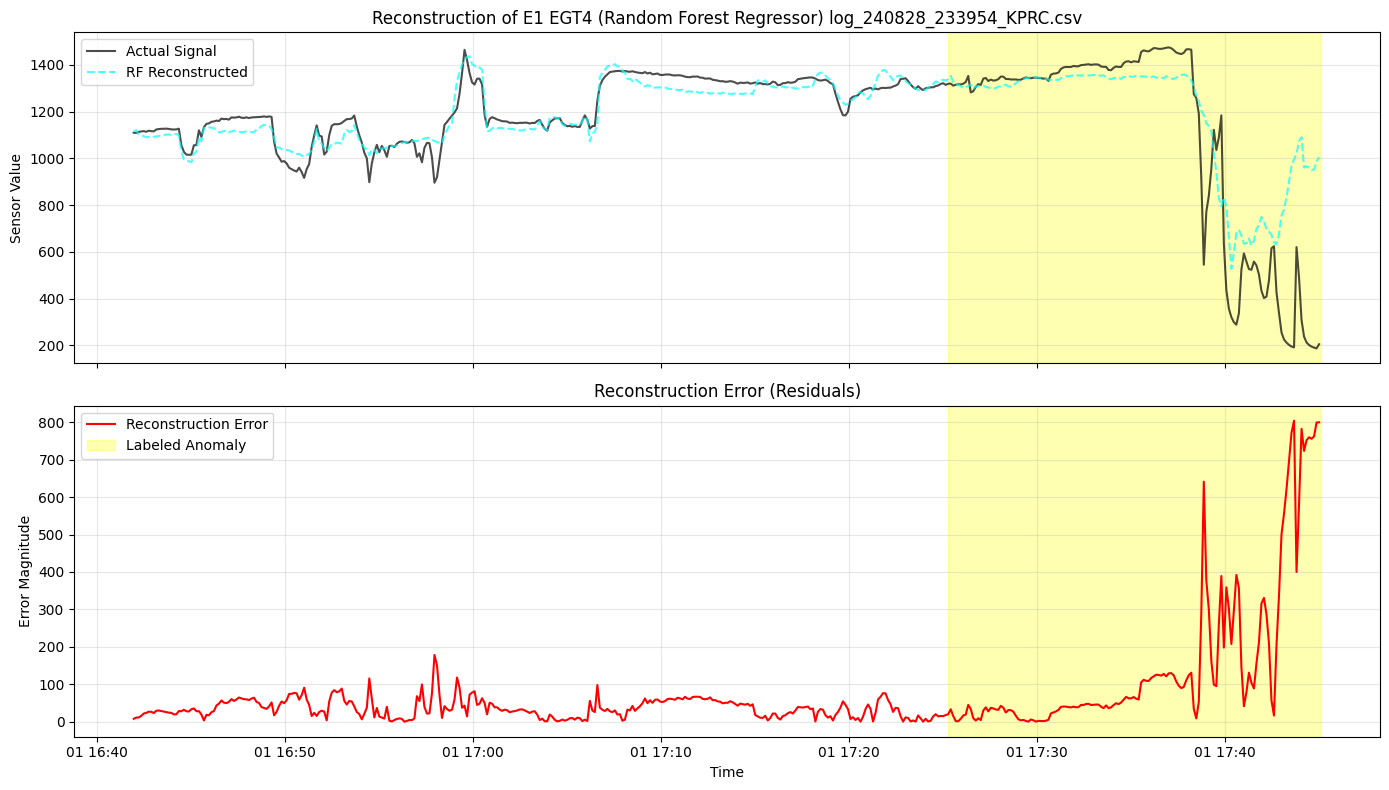

RMSE for log_240828_233954_KPRC.csv: 153.5881
--- Reconstructing E1 EGT4 for log_240911_162657_KPRC.csv ---


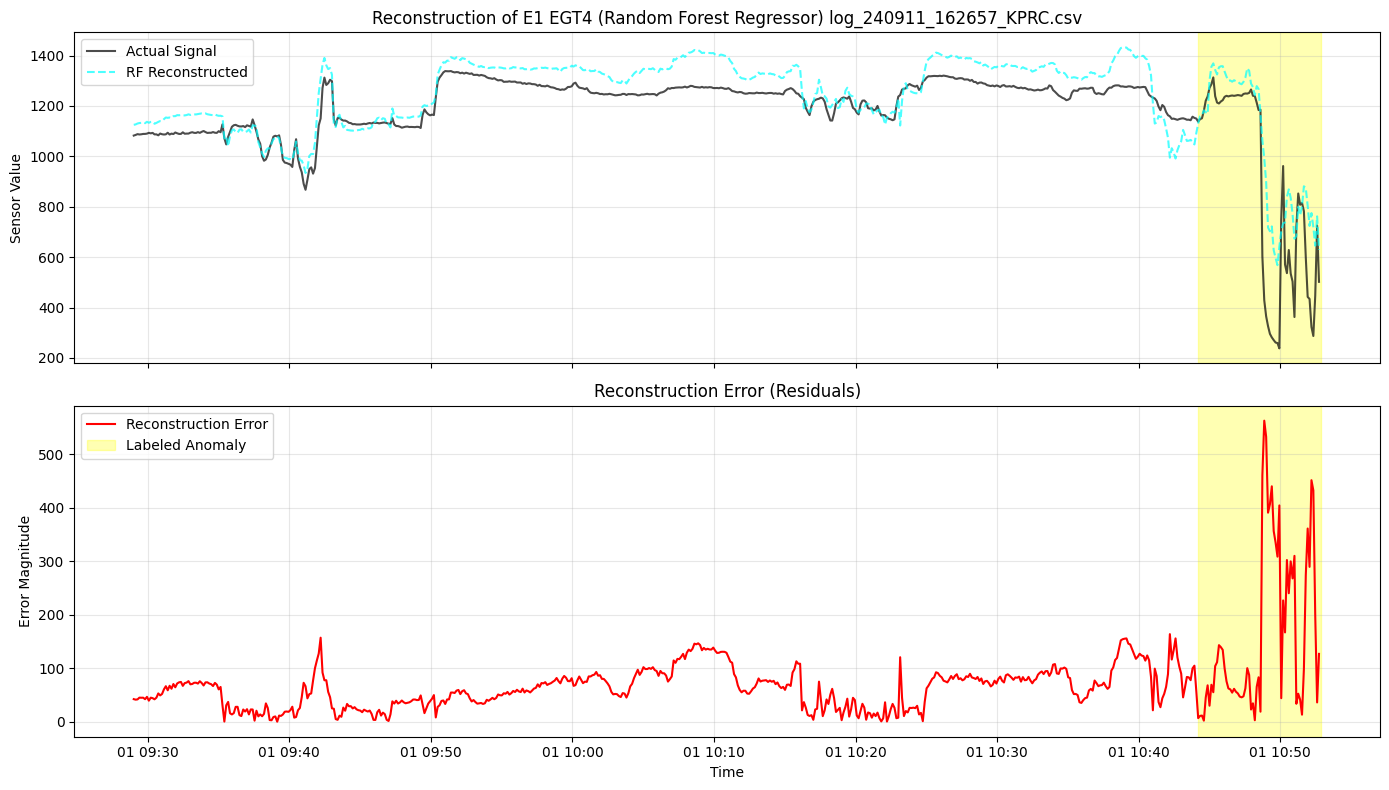

RMSE for log_240911_162657_KPRC.csv: 99.1607
--- Reconstructing E1 EGT4 for log_240928_135020_KPRC.csv ---


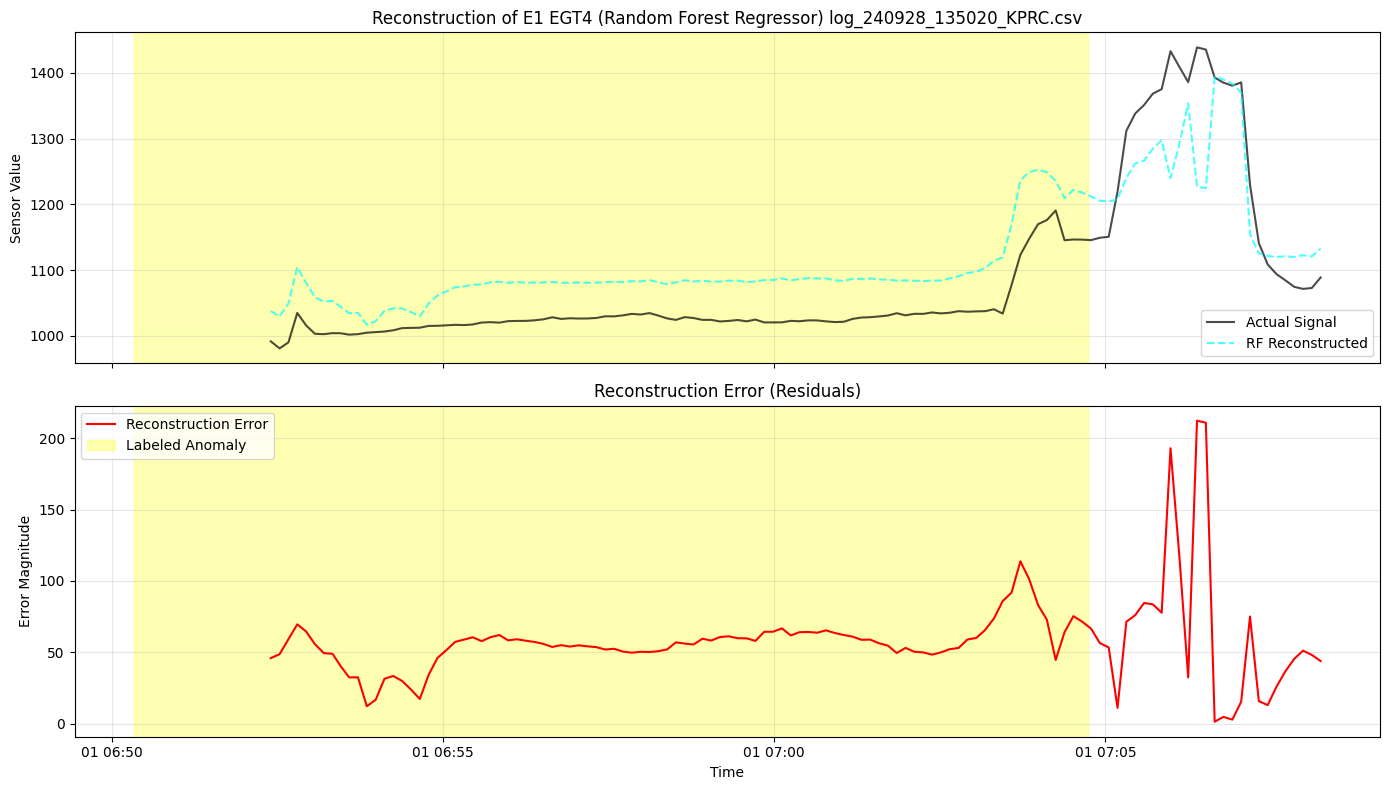

RMSE for log_240928_135020_KPRC.csv: 65.4181
--- Reconstructing E1 EGT4 for log_241003_133047_KPRC.csv ---


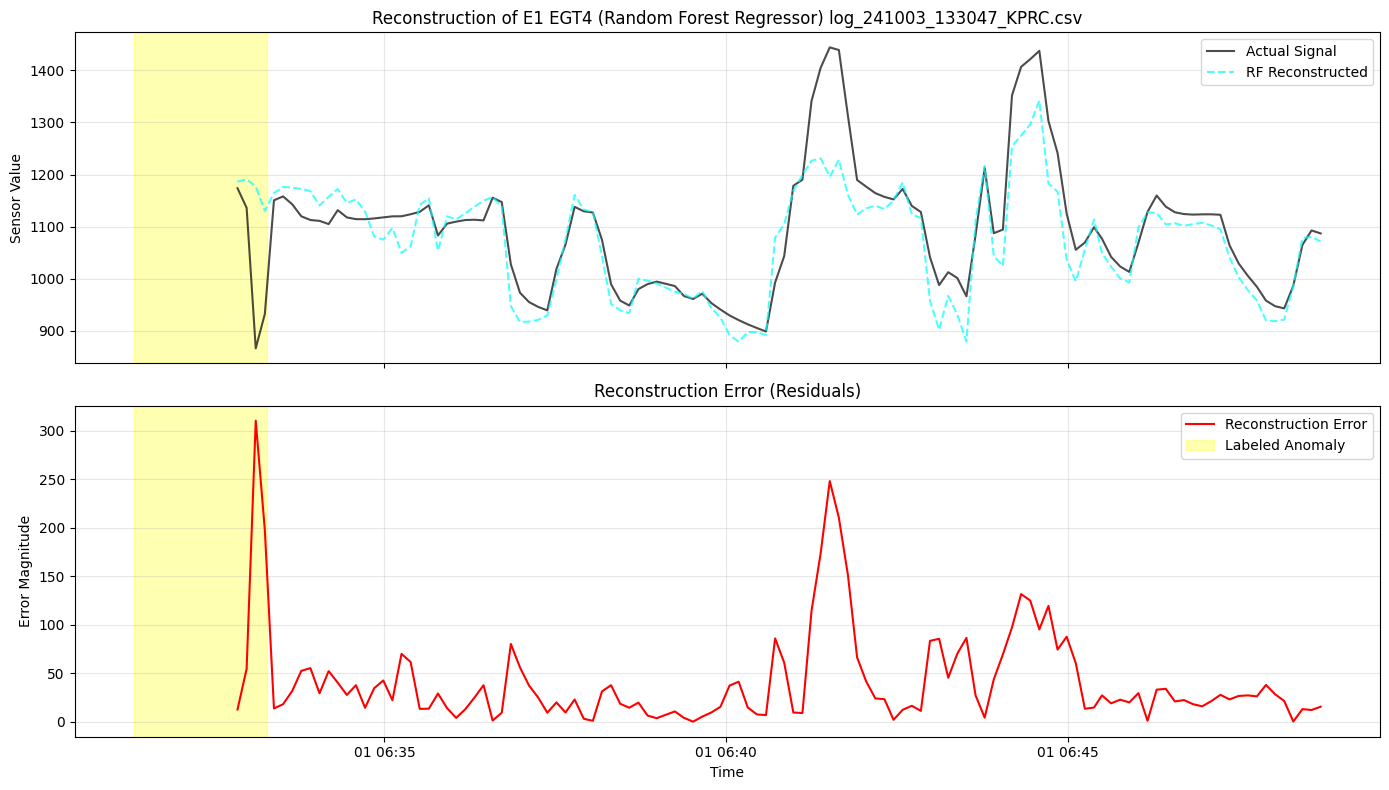

RMSE for log_241003_133047_KPRC.csv: 65.4911
--- Reconstructing E1 EGT4 for log_241008_132939_KPRC.csv ---


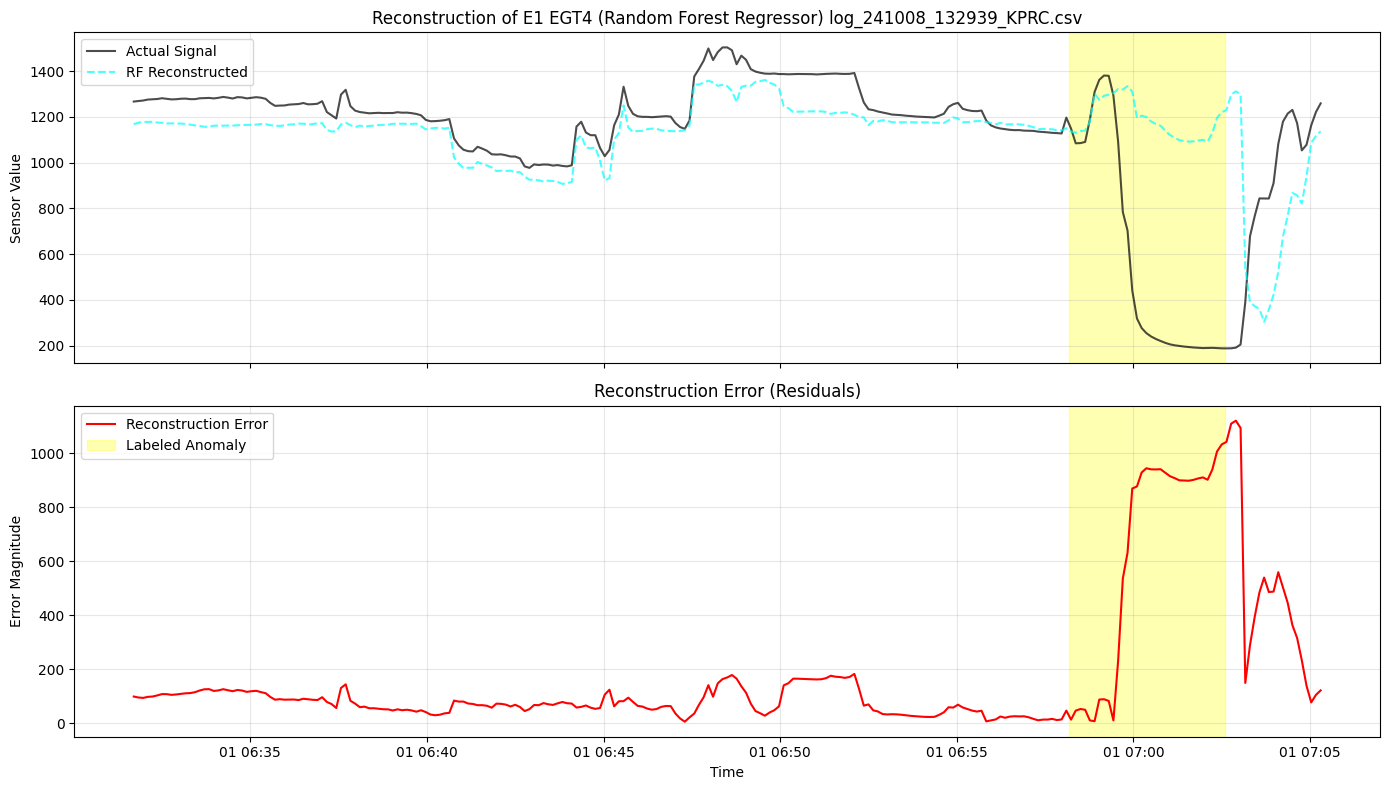

RMSE for log_241008_132939_KPRC.csv: 324.1310
--- Reconstructing E1 EGT4 for log_241030_192422_KPRC.csv ---


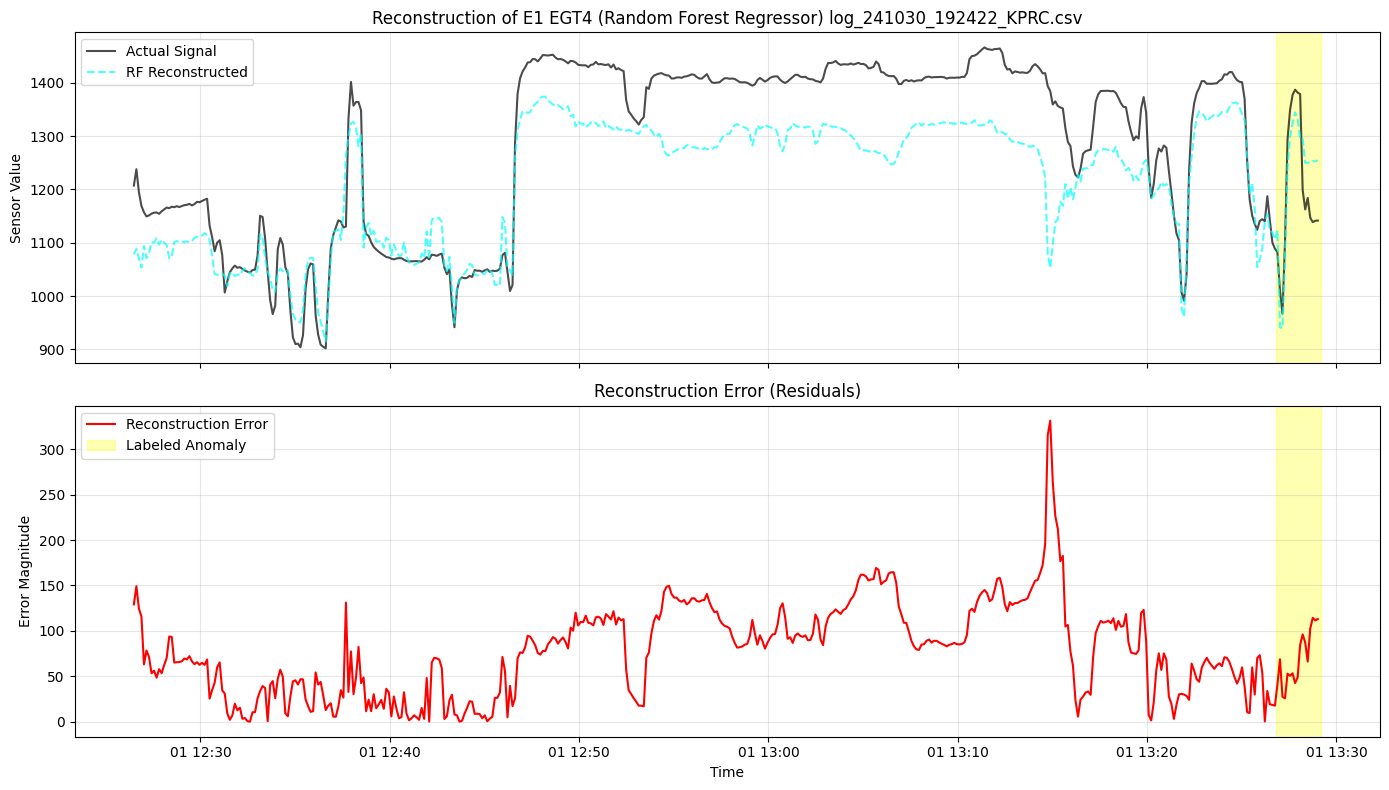

RMSE for log_241030_192422_KPRC.csv: 92.5979


In [8]:
from sklearn.ensemble import RandomForestRegressor
#from sklearn.model_selection import LeaveOneGroupOut

# 1. Identify your groups (Flight IDs)
flight_names = flightManager.list_all_files()
logo = LeaveOneGroupOut()

# --- CONFIGURATION ---
TARGET_SENSOR = COL_EGT  # The parameter you want to reconstruct/plot

# 2. Loop through for Cross-Validation (Training on all but one flight)
for train_idx, test_idx in logo.split(flight_names, groups=flight_names):
    train_flights = [flight_names[i] for i in train_idx]
    test_flight_name = flight_names[test_idx[0]]
    test_flight_obj = flightManager.get_flight(test_flight_name)

    print(f"--- Reconstructing {TARGET_SENSOR} for {test_flight_name} ---")

    # 1. Collect Training Data (Regression: y is the sensor value)
    X_train_list, y_train_list = [], []
    for fname in train_flights:
        f_obj = flightManager.get_flight(fname)
        # Use the NEW regression window function
        X, y = f_obj.createRegressionWindows(TARGET_SENSOR)
        X_train_list.append(X)
        y_train_list.append(y)
    
    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)

    # 2. Collect Testing Data
    X_test, y_test_actual = test_flight_obj.createRegressionWindows(TARGET_SENSOR)

    # 3. Train Random Forest Regressor
    # n_jobs=-1 uses all cores for speed
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train, y_train)

    # 4. Predict (Reconstruct) the signal
    y_test_pred = rf_reg.predict(X_test)

    # 5. Calculate Residuals (Reconstruction Error)
    residuals = np.abs(y_test_actual - y_test_pred)

    # 6. PLOTTING: Actual vs Reconstructed
    # Align time axis (accounting for window offset)
    # --- FIX STARTS HERE ---
    # 1. Start at the end of the first window
    start_idx = ROLLING_WINDOW_SIZE - 1
    
    # 2. Slice the dataframe with the stride: [start : end : step]
    # We take from start_idx to the end, stepping by STRIDE
    full_strided_time = test_flight_obj.dataframe[LOCAL_TIME].iloc[start_idx :: STRIDE]
    
    # 3. Clip it to match the exact length of your predictions 
    # (This handles any potential off-by-one mismatch at the very end of the file)
    time_axis = full_strided_time.iloc[:len(y_test_actual)]
    # --- FIX ENDS HERE ---
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Top Plot: Actual vs Predicted Signal
    ax1.plot(time_axis, y_test_actual, label='Actual Signal', color='black', alpha=0.7)
    ax1.plot(time_axis, y_test_pred, label='RF Reconstructed', color='cyan', alpha=0.7, linestyle='--')
    ax1.set_title(f"Reconstruction of {TARGET_SENSOR} (Random Forest Regressor) {test_flight_name}")
    ax1.set_ylabel("Sensor Value")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Bottom Plot: The Error (Residual)
    ax2.plot(time_axis, residuals, label='Reconstruction Error', color='red')
    
    # Optional: Highlight the labeled anomaly region if it exists
    if test_flight_obj.anomaly_label:
        start, end = test_flight_obj.anomaly_label
        # Convert to matplotlib date format for axvspan if needed, 
        # or just ensure time_axis matches the format.
        ax2.axvspan(start, end, color='yellow', alpha=0.3, label='Labeled Anomaly')
        # also highlight the actual signal plot for better visibility
        ax1.axvspan(start, end, color='yellow', alpha=0.3)

    ax2.set_title("Reconstruction Error (Residuals)")
    ax2.set_ylabel("Error Magnitude")
    ax2.set_xlabel("Time")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # calculate RMSE for reference
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"RMSE for {test_flight_name}: {rmse:.4f}")

    # If you want to use this for detection, you would threshold the 'residuals'
    # threshold = np.percentile(residuals, 99) # e.g., top 1% are anomalies

# LSTM 

In [ ]:
# Train LSTM (Long Short-Term Memory) Neural Network

# LSTM Training Function
def train_lstm_model(model, X_train, y_train, epochs=20, batch_size=32, lr=0.001):
    """
    X_train: Numpy array of shape (num_samples, window_size, 3)
    y_train: Numpy array of shape (num_samples,)
    """
    # 1. Convert Numpy arrays to PyTorch Tensors
    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.FloatTensor(y_train).view(-1, 1) # Reshape to (N, 1)

    # 2. Create DataLoader for batching
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 3. Setup Optimizer and Loss
    criterion = nn.BCELoss() # Binary Cross Entropy
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 4. Training Loop
    model.train() # Set to training mode
    print("Starting LSTM Training...")
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_y in loader:
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_X)
            
            # Calculate loss
            loss = criterion(predictions, batch_y)
            
            # Backward pass (Backprop)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        if (epoch+1) % 5 == 0:
            avg_loss = total_loss / len(loader)
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    print("Training Complete.")
    return model

# --- CONFIGURATION ---
WINDOW_SIZE = ROLLING_WINDOW_SIZE  # seconds per window
HIDDEN_SIZE = 64
EPOCHS = 20

# 1. PREPARE DATA
# Assuming 'flightManager' is already populated with flights
# We use a simple 80/20 split on the Flight IDs (Group Split)
all_flight_files = flightManager.list_all_files()
split_idx = int(len(all_flight_files) * 0.8)

train_files = all_flight_files[:split_idx]
test_files = all_flight_files[split_idx:]

print(f"Training on {len(train_files)} flights. Testing on {len(test_files)} flights.")

# Get Aggregated Training Data (3D Shape)
# Ensure you updated Manager to have 'get_data_for_flights' from previous answer
X_train, y_train = flightManager.get_data_for_flights(
    train_files, 
    window_size=WINDOW_SIZE, 
    is_lstm=True
)

print(f"Training Data Shape: {X_train.shape}")

# 2. INITIALIZE MODEL
model = LSTMAnomalyDetector(
    input_size=3,          # RPM, EGT, CHT
    hidden_size=HIDDEN_SIZE
)

print("X:", X_train.shape)
print("y:", y_train.shape)
print("Unique labels in X_train:", np.unique(X_train))
print("Unique labels in y_train:", np.unique(y_train))

# 3. SAFETY CHECK
# Ensure no NaNs and only 0/1
if np.isnan(X_train).any():
    print("Warning: X_train contains NaNs. Remove before training.")
    X_train = np.nan_to_num(X_train)    

# Force y_train to be 0 or 1 integers
y_train = y_train.astype(int)

# 3. TRAIN MODEL
# Note: labels should be 0 (Normal) or 1 (Anomaly)
model = train_lstm_model(model, X_train, y_train, epochs=EPOCHS)

Training on 9 flights. Testing on 3 flights.
Training Data Shape: (31624, 60, 3)
X: (31624, 60, 3)
y: (31624,)
Unique labels in X_train: [  60.9    61.25   61.65 ... 2624.5  2624.7      nan]
Unique labels in y_train: [0 1]
Starting LSTM Training...
Epoch 5/20 | Loss: 0.3791
Epoch 10/20 | Loss: 0.3794
Epoch 15/20 | Loss: 0.3755
Epoch 20/20 | Loss: 0.3703
Training Complete.


Predictions generated for log_240922_155102_KPRC.csv


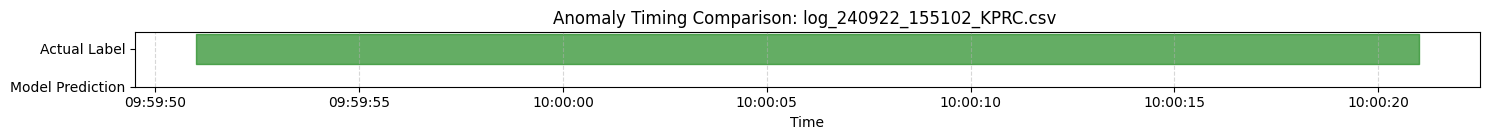

Predictions generated for log_241016_155942_KPRC.csv


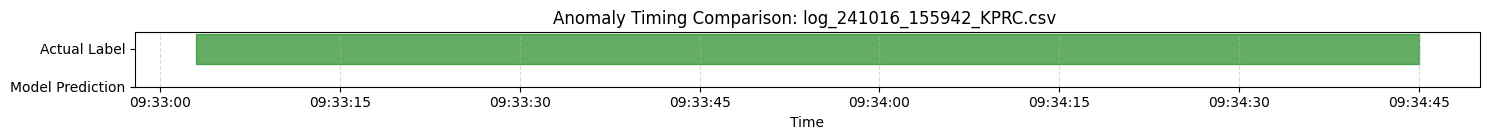

Predictions generated for log_241031_215027_KPRC.csv


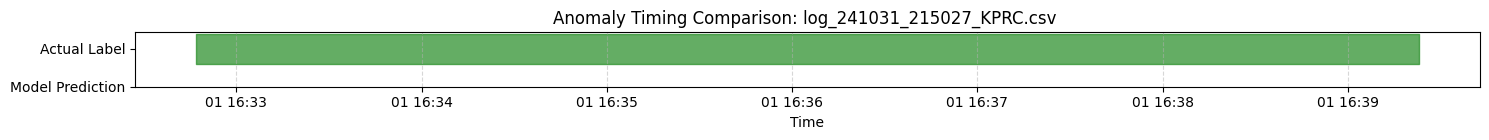

In [ ]:
# 4. EVALUATE ON TEST FLIGHTS
model.eval() # Set to evaluation mode

for test_file in test_files:
    test_flight = flightManager.get_flight(test_file)
    
    # Create windows for this specific flight
    X_test, y_test = test_flight.create_windows(window_size=WINDOW_SIZE, is_lstm=True)
    
    # Convert to Tensor
    X_test_tensor = torch.FloatTensor(X_test)
    
    # Predict
    with torch.no_grad():
        raw_preds = model(X_test_tensor)
        
    # Convert back to Numpy
    preds_numpy = raw_preds.numpy().flatten()
    
    # 5. ALIGN PREDICTIONS WITH DATAFRAME FOR PLOTTING
    # Because of windowing, the first (WINDOW_SIZE - 1) rows have no prediction.
    # We pad with 0s to align indices.
    df_len = len(test_flight.dataframe)
    preds_len = preds_numpy.shape[0]
    pad_len = df_len - preds_len
    if pad_len < 0:
        # More predictions than rows: truncate predictions
        full_preds = preds_numpy[:df_len]
    else:
        # Pad at the beginning
        padding = np.zeros(pad_len)
        full_preds = np.concatenate([padding, preds_numpy])
    # Ensure length matches
    assert len(full_preds) == df_len, f"full_preds ({len(full_preds)}) != dataframe ({df_len})"
    
    # Store in dataframe
    test_flight.dataframe[PREDICTED_ANOMALY_COL] = (full_preds > 0.5).astype(int) # Thresholding at 0.5
    
    # Add actual labels for comparison (if you haven't already)
    # (Assuming label_data_points() sets LABELED_ANOMALY_COL)
    test_flight.dataframe[LABELED_ANOMALY_COL] = test_flight.dataframe[LABELED_ANOMALY_COL].astype(int)

    print(f"Predictions generated for {test_file}")
    
    # Now you can call the plotting function we discussed!
    plot_anomaly_comparison(test_flight)

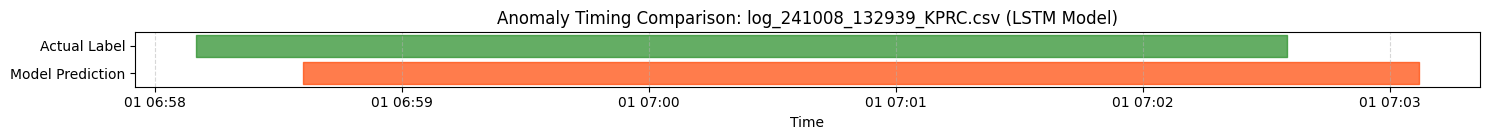

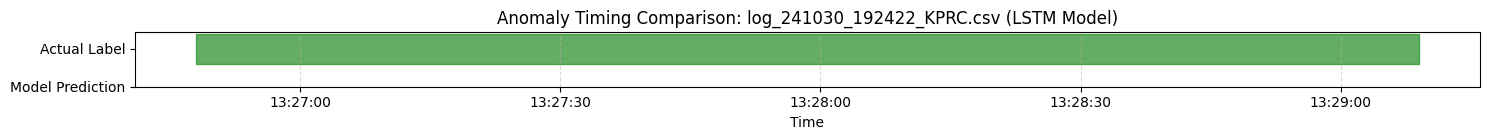

In [ ]:
#plot_anomaly_comparison(flightManager.get_flight('green/log_241008_132939_KPRC.csv'), title_suffix="(LSTM Model)")
#plot_anomaly_comparison(flightManager.get_flight('green/log_241030_192422_KPRC.csv'), title_suffix="(LSTM Model)")
plot_anomaly_comparison(flightManager.get_flight('log_241008_132939_KPRC.csv'), title_suffix="(LSTM Model)")
plot_anomaly_comparison(flightManager.get_flight('log_241030_192422_KPRC.csv'), title_suffix="(LSTM Model)")

In [ ]:
# --- ISOLATION FOREST ANOMALY DETECTION ---
testFlight = flightManager._flights[flightManager.list_all_files()[0]]
testFlight.detectAnomaliesIsolationForest(features=FEATURE_COLUMNS, contamination=CONTAMINATION_RATE)
print(f"Flight {testFlight.file_name}: Found {testFlight.dataframe[LABELED_ANOMALY_COL].sum()} anomalous data points.")
# Print the list of detected anomalies with their progress and scores
anomalies = testFlight.dataframe[testFlight.dataframe[PREDICTED_ANOMALY_COL] == True]
'''print("\nDetected Anomalies:")
for index, row in anomalies.iterrows():
    print(f"  Progress: {row[FLIGHT_PROGRESS_NORM]:.4f}, Anomaly Score: {row['anomaly_score']:.4f}")'''

"""for flight in flightManager._flights.values():
    flight.detectAnomaliesIsolationForest(features=FEATURE_COLUMNS, contamination=CONTAMINATION_RATE)
    # Summary of findings
    anomaly_count = flight.dataframe['is_anomaly'].sum()
    print(f"Flight {flight.file_name}: Found {anomaly_count} anomalous data points.")
"""

Flight log_240819_153520_KPRC.csv - Accuracy: 0.8971, Precision: 0.0065, Recall: 0.0061, F1-Score: 0.0063
Window 0-60 - Accuracy: 0.9825, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 1-61 - Accuracy: 0.9828, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 2-62 - Accuracy: 0.9831, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 3-63 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 4-64 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 5-65 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 6-66 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 7-67 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 8-68 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 9-69 - Accuracy: 0.9833, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000
Window 10-70 - Accuracy: 0.9833, Precision: 0.0000, Re

KeyboardInterrupt: 

AUTOENCODER LSTM

In [27]:
# AUTOENCODER LSTM MODEL

import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, sequence_len, n_features, hidden_dim=64):
        super(LSTMAutoencoder, self).__init__()
        self.sequence_len = sequence_len
        self.n_features = n_features
        self.hidden_dim = hidden_dim

        # Encoder
        self.encoder = nn.LSTM(n_features, hidden_dim, batch_first=True)
        
        # Decoder
        # The input to the decoder is the last hidden state of the encoder
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        # x shape: (batch_size, seq_len, n_features)
        
        # Encode: we only care about the final hidden state (h_n)
        _, (h_n, _) = self.encoder(x)
        h_n = h_n.permute(1, 0, 2) # (batch_size, 1, hidden_dim)
        
        # Repeat the hidden state for every timestep in the sequence
        # We broadcast h_n to (batch_size, sequence_len, hidden_dim)
        x_decoded = h_n.repeat(1, self.sequence_len, 1)
        
        # Decode
        x_decoded, _ = self.decoder(x_decoded)
        
        # Map back to original feature dimension
        x_reconstructed = self.output_layer(x_decoded)
        
        return x_reconstructed

def train_lstm_autoencoder(flight_manager, window_size=ROLLING_WINDOW_SIZE):
    # 1. Prepare Windowed Data (3D: Windows x Timesteps x Features)
    X_train, _ = flight_manager.prepare_supervised_data(window_size=window_size, is_lstm=True)
    
    # Flatten to scale, then reshape back to 3D
    scaler = StandardScaler()
    B, T, F = X_train.shape
    X_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(B, T, F)
    
    X_tensor = torch.FloatTensor(X_scaled)
    dataloader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

    model = LSTMAutoencoder(sequence_len=window_size, n_features=F)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # 2. Training Loop
    model.train()
    for epoch in range(30): # LSTM takes longer to converge than MLP
        total_loss = 0
        for batch in dataloader:
            inputs = batch[0]
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch} | Loss: {total_loss/len(dataloader):.6f}")

    # 3. Calculate Threshold 
    # Use the training data to see what "normal" reconstruction error looks like
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor)
        # Calculate MSE for each window
        mse_per_window = torch.mean((X_tensor - preds)**2, dim=(1, 2)).numpy()
    
    # Set threshold at 90th percentile to boost Recall (catch more anomalies)
    threshold = np.percentile(mse_per_window, 90)
    
    return model, scaler, threshold

# --- 1. Training ---
# Train on all 'Green' flights to establish a baseline of "Easy/Normal" behavior
# (train_lstm_autoencoder expects the flightManager, not the data array)
model, scaler, threshold = train_lstm_autoencoder(flightManager, window_size=ROLLING_WINDOW_SIZE)

Epoch 0 | Loss: nan
Epoch 5 | Loss: nan
Epoch 10 | Loss: nan
Epoch 15 | Loss: nan
Epoch 20 | Loss: nan
Epoch 25 | Loss: nan


RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 6204589816 bytes.

Green Flights: ['log_240819_153520_KPRC.csv', 'log_240828_233954_KPRC.csv', 'log_240911_162657_KPRC.csv', 'log_240928_135020_KPRC.csv', 'log_241003_133047_KPRC.csv', 'log_241008_132939_KPRC.csv', 'log_241030_192422_KPRC.csv']
Red Flights: ['log_240610_222704_KPRC.csv', 'log_240721_173642_KPRC.csv', 'log_240922_155102_KPRC.csv', 'log_241016_155942_KPRC.csv', 'log_241031_215027_KPRC.csv']
Flight log_240610_222704_KPRC.csv: Found 0 anomalous points (Threshold: nan)


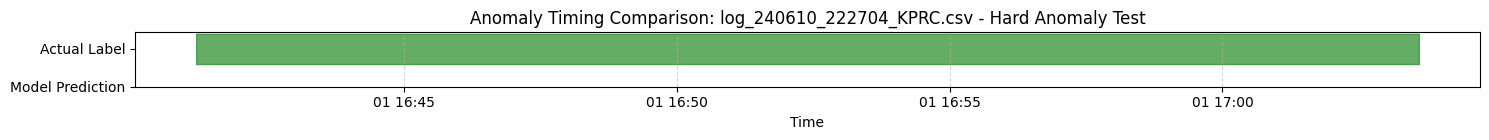

Flight log_240721_173642_KPRC.csv: Found 0 anomalous points (Threshold: nan)


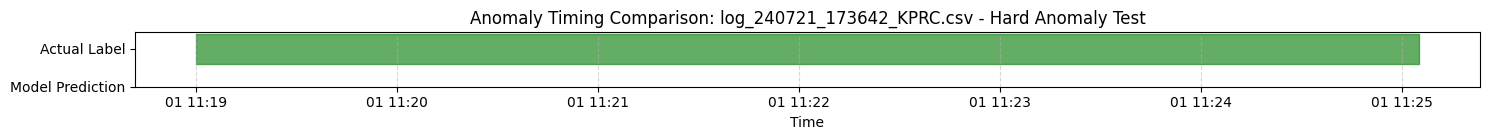

Flight log_240922_155102_KPRC.csv: Found 0 anomalous points (Threshold: nan)


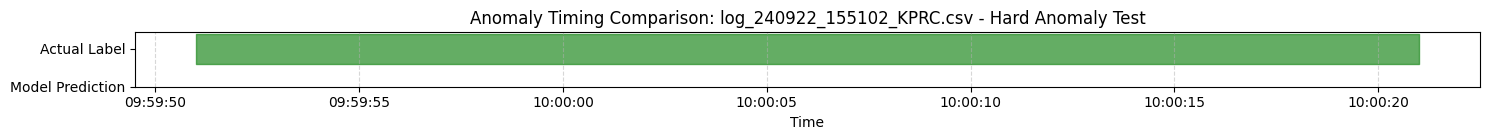

Flight log_241016_155942_KPRC.csv: Found 0 anomalous points (Threshold: nan)


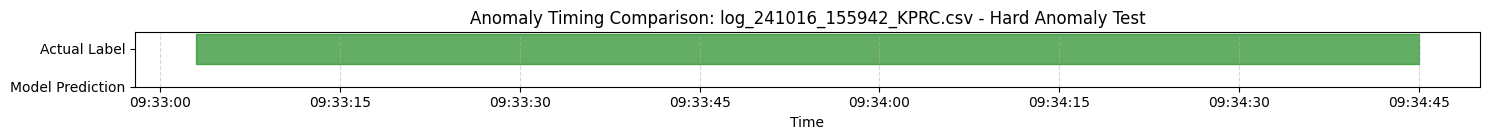

Flight log_241031_215027_KPRC.csv: Found 0 anomalous points (Threshold: nan)


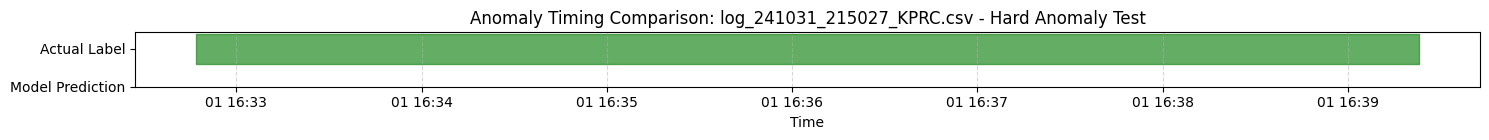

In [25]:
# Group your flight names based on their file_path metadata (store only filename)
green_flights = [f for f in flightManager.list_all_files() if "green" in flightManager.get_flight(f).file_path]
red_flights = [f for f in flightManager.list_all_files() if "red" in flightManager.get_flight(f).file_path]
print(f"Green Flights: {green_flights}")
print(f"Red Flights: {red_flights}")

# --- 2. Testing ---
# Evaluate on 'Red' flights to see if we've solved the recall problem
for test_file in red_flights:
    test_flight = flightManager.get_flight(test_file)
    test_flight.detectAnomaliesLSTM_AE(model, scaler, threshold)
    plot_anomaly_comparison(test_flight, title_suffix="- Hard Anomaly Test")


# Extra Stuff

## Convert time of flight to normalized flight progress

In [ ]:
# Print Converted anomaly label times to normalized flight progress, ensure progress is between 0 and 1
for flight in flightManager._flights.values():
    if flight.anomaly_label:
        start_anom, end_anom = flight.anomaly_label
        total_duration = flight.get_duration().total_seconds()
        print(flight.file_name)
        start_progress = (start_anom - flight.start_time).total_seconds() / total_duration
        end_progress = (end_anom - flight.start_time).total_seconds() / total_duration
        print(f"  Anomaly Start Time: {start_anom}, Normalized Progress: {start_progress:.4f}")
        print(f"  Anomaly End Time: {end_anom}, Normalized Progress: {end_progress:.4f}")

## Find Lowest Correlation Spike

In [ ]:
'''
def findLowestCorrelation(Flight, data1, data2):
    """
    Finds the lowest absolute correlation (closest to 0) point based on 2 given data columns 
    and displays the raw engine data in a window around that anomaly.
    """
    if Flight.dataframe.empty or data1 not in Flight.dataframe.columns or data2 not in Flight.dataframe.columns:
        print(f"Cannot analyze anomaly for {Flight.file_name}: Data or correlation column missing.")
        return

    min_corr_index = Flight.dataframe[data1].rolling(window=ROLLING_WINDOW_SIZE).corr(Flight.dataframe[data2]).idxmin()
    start_index = max(0, min_corr_index - ROLLING_WINDOW_SIZE)
    end_index = min(len(Flight.dataframe), min_corr_index + ROLLING_WINDOW_SIZE + 1)
    anomaly_slice = Flight.dataframe.iloc[start_index:end_index].copy()

    print(f"\n--- Rolling Correlation Anomaly (Min {data1} / {data2} Correlation): {Flight.file_name} ---")
    print(f"Lowest Correlation of {Flight.dataframe[data1].rolling(window=ROLLING_WINDOW_SIZE).corr(Flight.dataframe[data2]).min():.4f} found at Progress: {anomaly_slice.loc[min_corr_index, FLIGHT_PROGRESS_NORM]:.4f}")

findLowestCorrelation(flightManager._flights[flightManager.list_all_files()[0]], COL_RPM, COL_EGT)
findLowestCorrelation(flightManager._flights[flightManager.list_all_files()[0]], COL_RPM, COL_CHT)
findLowestCorrelation(flightManager._flights[flightManager.list_all_files()[0]], COL_CHT, COL_EGT)
'''


--- Rolling Correlation Anomaly (Min E1 RPM / E1 EGT4 Correlation): log_240819_153520_KPRC.csv ---
Lowest Correlation of -0.7224 found at Progress: 0.3401

--- Rolling Correlation Anomaly (Min E1 RPM / E1 CHT4 Correlation): log_240819_153520_KPRC.csv ---
Lowest Correlation of -0.9518 found at Progress: 0.6914

--- Rolling Correlation Anomaly (Min E1 CHT4 / E1 EGT4 Correlation): log_240819_153520_KPRC.csv ---
Lowest Correlation of -0.9772 found at Progress: 0.5265


## Plot Rolling Correlation For A Flight

In [ ]:
flightManager._flights[flightManager.list_all_files()[0]].plotEngineCorrelation(COL_RPM, COL_EGT)
flightManager._flights[flightManager.list_all_files()[0]].plotEngineCorrelation(COL_RPM, COL_CHT)
flightManager._flights[flightManager.list_all_files()[0]].plotEngineCorrelation(COL_CHT, COL_EGT)

## Plot Timeseries Engine Parameters For One Flight

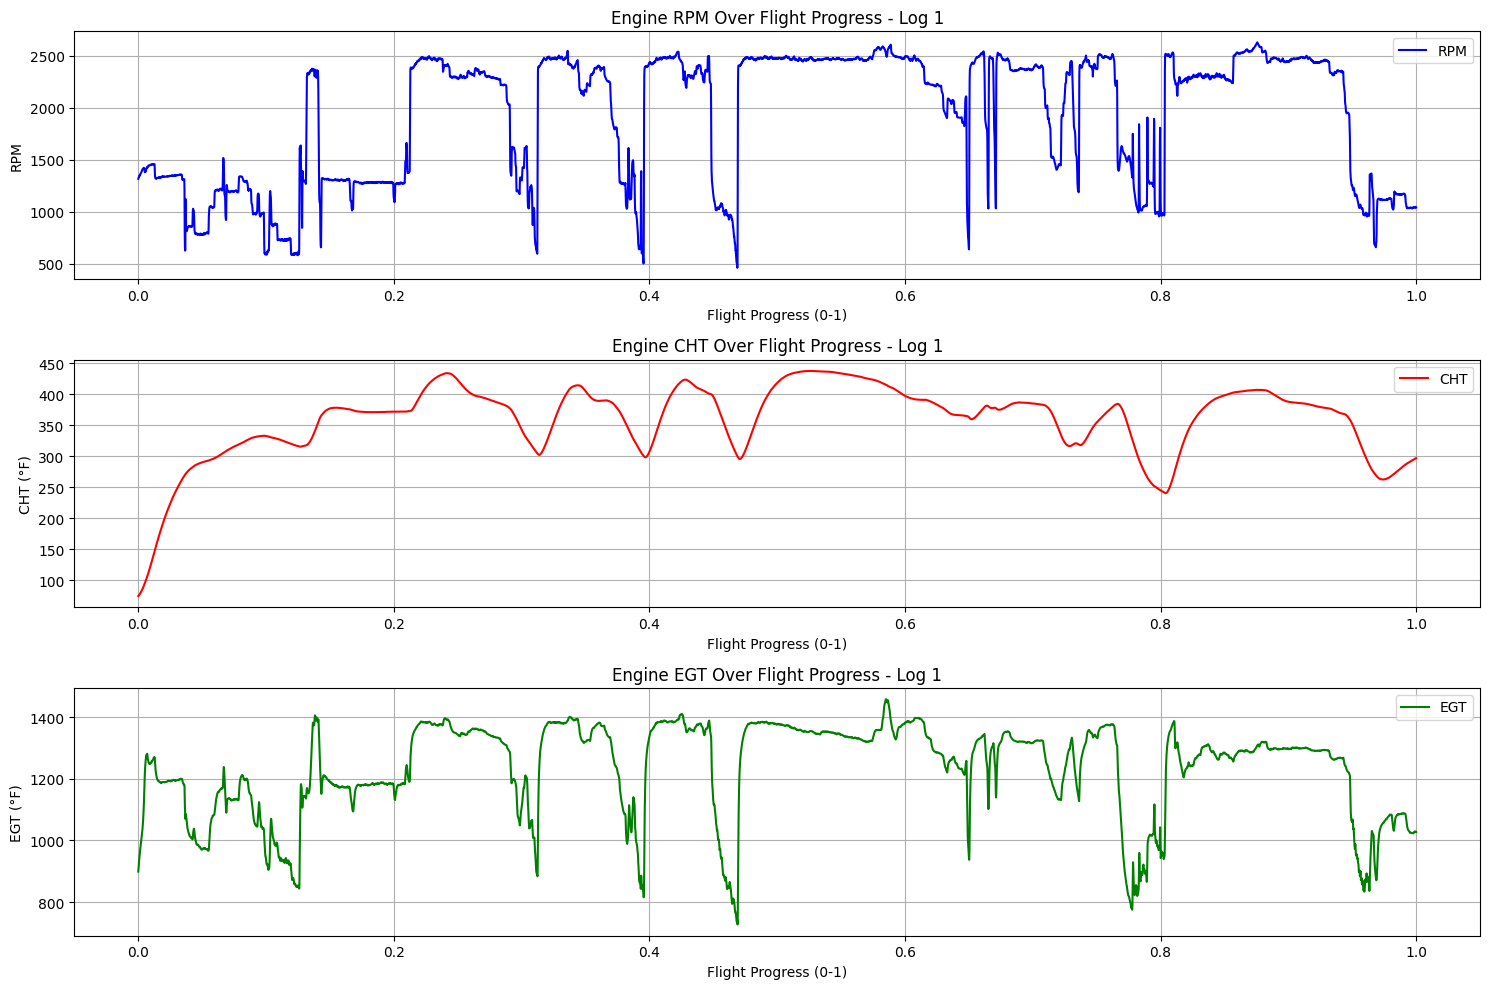

In [9]:
def plotEngineParameters(df, title="Engine Parameters Over Flight Progress"):
    """
    Plots the engine parameters RPM, CHT, and EGT over normalized flight progress.
    """
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.plot(df[FLIGHT_PROGRESS_NORM], df[COL_RPM], label='RPM', color='blue')
    plt.title(f'Engine RPM Over Flight Progress - {title}')
    plt.xlabel('Flight Progress (0-1)')
    plt.ylabel('RPM')
    plt.legend()
    plt.grid()

    plt.subplot(3, 1, 2)
    plt.plot(df[FLIGHT_PROGRESS_NORM], df[COL_CHT], label='CHT', color='red')
    plt.title(f'Engine CHT Over Flight Progress - {title}')
    plt.xlabel('Flight Progress (0-1)')
    plt.ylabel('CHT (°F)')
    plt.legend()
    plt.grid()

    plt.subplot(3, 1, 3)
    plt.plot(df[FLIGHT_PROGRESS_NORM], df[COL_EGT], label='EGT', color='green')
    plt.title(f'Engine EGT Over Flight Progress - {title}')
    plt.xlabel('Flight Progress (0-1)')
    plt.ylabel('EGT (°F)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plotEngineParameters(flightManager._flights[flightManager.list_all_files()[0]].dataframe, title="Log 1")
